# Описание ДЗ-3.

В третьей домашке необходимо для датасета животных обучить MLP.
2. Использовать Custom Dataset, Sampler, collate_fn
3. Сделать предобработку фичей
4. Попробовать BatchNorm1d, Dropout
5. Подключить для логирования tensorboard и/или mlflow
6. Не забыть разделить выборку на train/valid в соотношении 80/20%
7. Получить точность не ниже 65%.
8. Сравнить результаты при разных подходах: 1) Масштабировать данные StandardScaler'ом + не использовать BatchNorm после Input слоя 2) Не Масштабировать данные + использовать BatchNorm после Input слоя 3) StandardScaler + BatchNorm

*В папке LESS  можно найти примеры использования всех необходимых либ для выполнения данной работы*

За дз можно получить максимум 15 баллов. **Домашки довольно творческие, если замечу копию нотбука у другого студента то максимальный балл сниижается до 3 )**

Разбалловка:
*   **Воспроизводимость и читабельность кода -  11 баллов** (все воспроизвелось и все понятно для проверяющего - 11 баллов; есть непонятные моменты, но все воспроизвелось - 6 балла; непонятный код и/или воспроизводится с небольшой правкой - 3 балл; непонятный код и/или ничего не воспроизвелось - 0 баллов).
*   **Технический отчет - 4 балла** (приведены результаты сравнения и выводы что сделали чтоб перебить baseline\другую модель, к примеру одна модель лучше/хуже нейронки и тд - 4 балла, только результаты - 2 балл, ничего нет - 0 баллов).


**Присылать домашки по ссылке https://forms.gle/W8jwbwA4EWagEbX66**

In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split, Sampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import mlflow
from torch.utils.tensorboard import SummaryWriter
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import sklearn.preprocessing as ppc
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import warnings

warnings.filterwarnings("ignore")

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [2]:
torch.manual_seed(69)
np.random.seed(69)

SEED = 69

### функции

In [3]:
def build_pipe(data: pd.DataFrame) -> Pipeline:
    categorical_cols = data.select_dtypes(
        include=[
            "object",
            "category",
        ]
    ).columns.tolist()

    num_cols = data.select_dtypes(include=[np.number]).columns.tolist()

    return Pipeline(
        steps=[
            (
                "preprocessor",
                ColumnTransformer(
                    transformers=[
                        (
                            "num",
                            Pipeline(
                                steps=[
                                    ("imputer", SimpleImputer(strategy="mean")),
                                    (
                                        "transformer",
                                        ppc.SplineTransformer(
                                            n_knots=7,
                                            degree=7,
                                            order="F",
                                            extrapolation="linear",
                                        ),
                                    ),
                                ]
                            ),
                            num_cols,
                        ),
                        (
                            "cat",
                            Pipeline(
                                steps=[
                                    (
                                        "encoder",
                                        ppc.OneHotEncoder(handle_unknown="ignore"),
                                    )
                                ]
                            ),
                            categorical_cols,
                        ),
                    ]
                ),
            ),
            # ("poly", ppc.PolynomialFeatures(2)),
        ]
    )

In [4]:
class AnimalDataset(Dataset):
    def __init__(self, features, labels, transform=None):
        self.features = features
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.features[idx]
        y = self.labels[idx]

        if self.transform:
            x = self.transform(x)

        return x, y


def collate_fn(batch):
    features = torch.tensor([item[0] for item in batch], dtype=torch.float32)
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    return features, labels

In [ ]:
class StratifiedBatchSampler(Sampler):
    def __init__(self, labels, batch_size):
        self.labels = labels
        self.batch_size = batch_size
        self.class_indices = {}

        for idx, label in enumerate(labels):
            if label not in self.class_indices:
                self.class_indices[label] = []
            self.class_indices[label].append(idx)

        self.samples_per_class = batch_size // len(self.class_indices)

    def __iter__(self):
        for label in self.class_indices:
            np.random.shuffle(self.class_indices[label])

        batches = []
        remaining_indices = {
            label: indices.copy() for label, indices in self.class_indices.items()
        }

        while (
            sum(len(indices) for indices in remaining_indices.values())
            >= self.batch_size
        ):
            batch = []

            for label, indices in remaining_indices.items():
                samples_to_take = min(self.samples_per_class, len(indices))

                if samples_to_take > 0:
                    batch.extend(indices[:samples_to_take])
                    remaining_indices[label] = indices[samples_to_take:]

            if len(batch) < self.batch_size:
                all_remaining = [
                    idx for indices in remaining_indices.values() for idx in indices
                ]
                if all_remaining:
                    additional = np.random.choice(
                        all_remaining,
                        min(self.batch_size - len(batch), len(all_remaining)),
                        replace=False,
                    )
                    batch.extend(additional)

                    # Remove the used indices
                    for label in remaining_indices:
                        remaining_indices[label] = [
                            idx
                            for idx in remaining_indices[label]
                            if idx not in additional
                        ]

            np.random.shuffle(batch)
            batches.append(batch)

        return iter([idx for batch in batches for idx in batch])

    def __len__(self):
        return len(self.labels)

In [ ]:
class MLP(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        output_size,
        use_batchnorm=True,
        dropout_rate=0.5,
    ):
        super(MLP, self).__init__()

        self.use_batchnorm = use_batchnorm
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size) if use_batchnorm else nn.Identity()
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.bn2 = nn.BatchNorm1d(hidden_size // 2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(hidden_size // 2, output_size)

    def forward(self, x):
        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        return x


def train_model(
    X_train,
    y_train,
    X_test,
    y_test,
    use_scaler=True,
    use_batchnorm=True,
    hidden_size=128,
    batch_size=32,
    lr=0.001,
    epochs=30,
):

    if use_scaler:
        scaler = ppc.StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    train_dataset = AnimalDataset(X_train, y_train)
    val_dataset = AnimalDataset(X_test, y_test)

    train_sampler = StratifiedBatchSampler(y_train, batch_size)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=train_sampler,
        collate_fn=collate_fn,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
    )

    input_size = X_train.shape[1]
    output_size = len(np.unique(y_train))

    model = MLP(input_size, hidden_size, output_size, use_batchnorm=use_batchnorm)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    writer = SummaryWriter(
        f"runs/animal_model_scaler_{use_scaler}_batchnorm_{use_batchnorm}"
    )

    mlflow.set_experiment("Animal_Classification_MLP")

    with mlflow.start_run(
        run_name=f"mlp_scaler_{use_scaler}_batchnorm_{use_batchnorm}"
    ):
        mlflow.log_params(
            {
                "hidden_size": hidden_size,
                "batch_size": batch_size,
                "learning_rate": lr,
                "epochs": epochs,
                "use_scaler": use_scaler,
                "use_batchnorm": use_batchnorm,
            }
        )

        train_losses = []
        val_losses = []
        train_accs = []
        val_accs = []

        for epoch in range(epochs):
            model.train()
            train_loss = 0.0
            train_preds = []
            train_true = []

            for features, labels in tqdm(
                train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training"
            ):
                features = features.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()
                outputs = model(features)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                train_preds.extend(predicted.cpu().numpy())
                train_true.extend(labels.cpu().numpy())

            model.eval()
            val_loss = 0.0
            val_preds = []
            val_true = []

            with torch.no_grad():
                for features, labels in val_loader:
                    features = features.to(device)
                    labels = labels.to(device)

                    outputs = model(features)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()

                    _, predicted = torch.max(outputs, 1)
                    val_preds.extend(predicted.cpu().numpy())
                    val_true.extend(labels.cpu().numpy())

            train_loss /= len(train_loader)
            val_loss /= len(val_loader)
            train_acc = accuracy_score(train_true, train_preds)
            val_acc = accuracy_score(val_true, val_preds)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)

            writer.add_scalar("Loss/train", train_loss, epoch)
            writer.add_scalar("Loss/validation", val_loss, epoch)
            writer.add_scalar("Accuracy/train", train_acc, epoch)
            writer.add_scalar("Accuracy/validation", val_acc, epoch)

            mlflow.log_metrics(
                {
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "train_accuracy": train_acc,
                    "val_accuracy": val_acc,
                },
                step=epoch,
            )

            print(
                f"Epoch {epoch+1}/{epochs} - "
                f"Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f}, "
                f"Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}"
            )

        mlflow.pytorch.log_model(model, "model")
        writer.close()

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label="Train")
        plt.plot(val_losses, label="Validation")
        plt.title("Loss Curves")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(train_accs, label="Train")
        plt.plot(val_accs, label="Validation")
        plt.title("Accuracy Curves")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()

        plt.tight_layout()
        plt.show()

        return model, val_acc

### код

In [7]:
X = pd.read_csv("./data/X_cat.csv", sep="\t")
y = pd.read_csv("./data/y_cat.csv", sep="\t")

df = pd.merge(X, y, on="Id", how="inner")
df.drop(columns=["Id"], inplace=True)
df.head()

target_col = "Status"

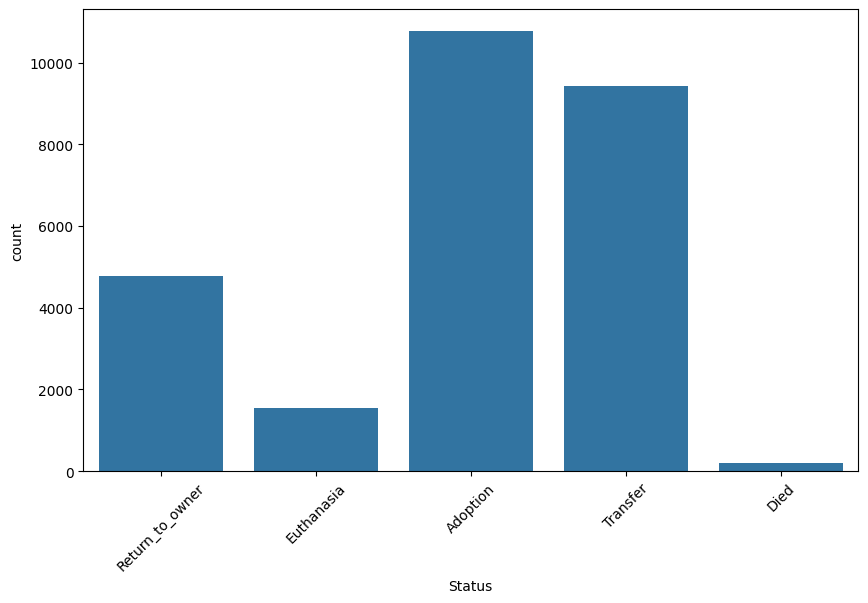

In [ ]:
plt.figure(figsize=(4, 3))
sns.countplot(x="Status", data=df)
plt.xticks(rotation=45)
plt.show()

In [9]:
X = df.drop(target_col, axis=1).values
y = pd.Categorical(df[target_col]).codes

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

In [10]:
pipe = build_pipe(data=pd.DataFrame(X_train))
X_train_processed = pipe.fit_transform(X_train)
X_test_processed = pipe.transform(X_test)


1. StandardScaler + No BatchNorm


Epoch 1/30 - Training:   0%|          | 0/669 [00:00<?, ?it/s]

Epoch 1/30 - Train loss: 0.8555, Train acc: 0.6376, Val loss: 1.3684, Val acc: 0.6264


Epoch 2/30 - Training:   0%|          | 0/669 [00:00<?, ?it/s]

Epoch 2/30 - Train loss: 0.8474, Train acc: 0.6623, Val loss: 1.2947, Val acc: 0.6289


...

Epoch 29/30 - Training:   0%|          | 0/669 [00:00<?, ?it/s]

Epoch 29/30 - Train loss: 0.8108, Train acc: 0.6737, Val loss: 1.0702, Val acc: 0.6360


Epoch 30/30 - Training:   0%|          | 0/669 [00:00<?, ?it/s]

Epoch 30/30 - Train loss: 0.8161, Train acc: 0.6725, Val loss: 1.0923, Val acc: 0.6354


2025/05/26 19:18:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


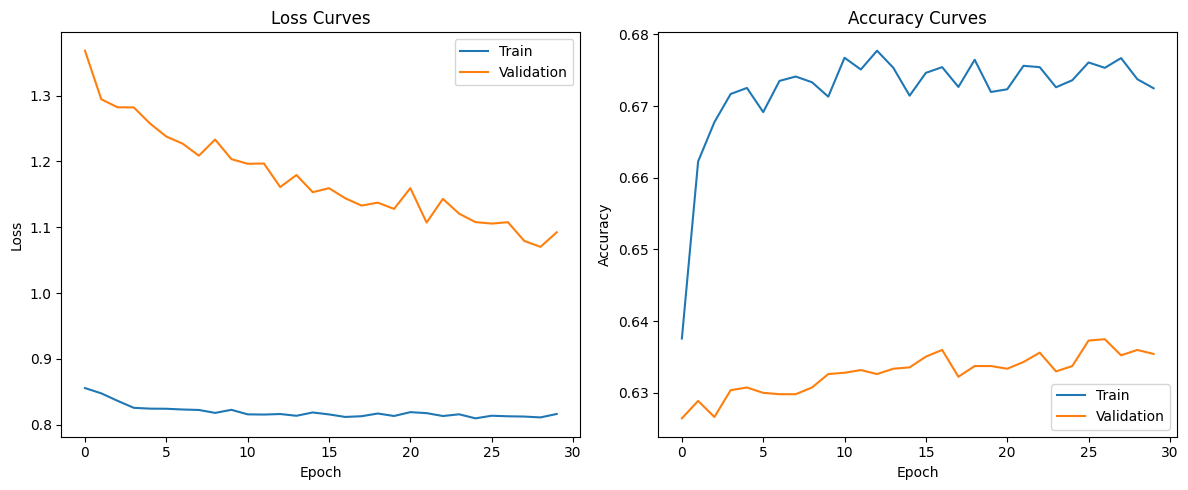


2. No StandardScaler + BatchNorm


Epoch 1/30 - Training:   0%|          | 0/669 [00:00<?, ?it/s]

Epoch 1/30 - Train loss: 0.8600, Train acc: 0.6318, Val loss: 1.3782, Val acc: 0.6156


Epoch 2/30 - Training:   0%|          | 0/669 [00:00<?, ?it/s]

Epoch 2/30 - Train loss: 0.8592, Train acc: 0.6560, Val loss: 1.3171, Val acc: 0.6214


...

Epoch 10/30 - Train loss: 0.8271, Train acc: 0.6722, Val loss: 1.2009, Val acc: 0.6296


Epoch 11/30 - Training:   0%|          | 0/669 [00:00<?, ?it/s]

Epoch 11/30 - Train loss: 0.8205, Train acc: 0.6751, Val loss: 1.1975, Val acc: 0.6306


Epoch 12/30 - Training:   0%|          | 0/669 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [11]:
results = {}

print("\n1. StandardScaler + No BatchNorm")
model1, acc1 = train_model(
    X_train_processed,
    y_train,
    X_test_processed,
    y_test,
    use_scaler=True,
    use_batchnorm=False,
)
results["StandardScaler + No BatchNorm"] = acc1

print("\n2. No StandardScaler + BatchNorm")
model2, acc2 = train_model(
    X_train_processed,
    y_train,
    X_test_processed,
    y_test,
    use_scaler=False,
    use_batchnorm=True,
)
results["No StandardScaler + BatchNorm"] = acc2

print("\n3. StandardScaler + BatchNorm")
model3, acc3 = train_model(
    X_train_processed,
    y_train,
    X_test_processed,
    y_test,
    use_scaler=True,
    use_batchnorm=True,
)
results["StandardScaler + BatchNorm"] = acc3

In [ ]:
for config, acc in results.items():
    print(f"{config}: {acc:.4f}")

plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values())
plt.ylim(0, 1)
plt.ylabel("Validation Accuracy")
plt.title("Comparison of Different Configurations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n--- Technical Report ---")
best_config = max(results, key=results.get)
print(f"Best configuration: {best_config} with accuracy {results[best_config]:.4f}")
print(
    f"Comparing with baseline (StandardScaler + No BatchNorm): {(results[best_config] - results['StandardScaler + No BatchNorm']) * 100:.2f}% improvement"
)
print("\nConclusions:")
if best_config == "StandardScaler + BatchNorm":
    print(
        "Using both StandardScaler and BatchNorm provided the best results, suggesting that the two methods complement each other."
    )
elif best_config == "No StandardScaler + BatchNorm":
    print(
        "BatchNorm alone was sufficient for normalizing the data, making StandardScaler redundant or even detrimental."
    )
else:
    print(
        "StandardScaler alone performed better than using BatchNorm, suggesting that BatchNorm might be interfering with the learning process for this dataset."
    )